In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Simulate A/B testing data

np.random.seed(42)

sample_size = 1000

control = np.random.binomial(
    1,
    0.10,
    sample_size
)

experiment = np.random.binomial(
    1,
    0.13,
    sample_size
)

ab_data = pd.DataFrame({
    "Group": (
        ["Control"] * sample_size +
        ["Experiment"] * sample_size
    ),
    "Converted": np.concatenate([
        control,
        experiment
    ])
})

print("A/B testing dataset created!")
print("Total observations:", len(ab_data))

ab_data.head()

A/B testing dataset created!
Total observations: 2000


,Group,Converted
0,Control,0
1,Control,1
2,Control,0
3,Control,0
4,Control,0


In [3]:
# Calculate conversion rates

conversion_summary = ab_data.groupby("Group")["Converted"].agg(
    Users="count",
    Conversions="sum",
    ConversionRate="mean"
).reset_index()

conversion_summary["ConversionRate"] = (
    conversion_summary["ConversionRate"] * 100
)

conversion_summary["ConversionRate"] = (
    conversion_summary["ConversionRate"].round(2)
)

conversion_summary

,Group,Users,Conversions,ConversionRate
0,Control,1000,100,10.0
1,Experiment,1000,131,13.1


In [4]:
# Calculate relative improvement

control_rate = conversion_summary.loc[
    conversion_summary["Group"] == "Control",
    "ConversionRate"
].iloc[0]

experiment_rate = conversion_summary.loc[
    conversion_summary["Group"] == "Experiment",
    "ConversionRate"
].iloc[0]

absolute_difference = experiment_rate - control_rate

relative_improvement = (
    absolute_difference / control_rate
) * 100

print("Control Conversion Rate:", control_rate, "%")
print("Experiment Conversion Rate:", experiment_rate, "%")
print("Absolute Difference:", round(absolute_difference, 2), "percentage points")
print("Relative Improvement:", round(relative_improvement, 2), "%")

Control Conversion Rate: 10.0 %
Experiment Conversion Rate: 13.1 %
Absolute Difference: 3.1 percentage points
Relative Improvement: 31.0 %


In [5]:
from statsmodels.stats.proportion import proportions_ztest

control_conversions = int(
    ab_data.loc[
        ab_data["Group"] == "Control",
        "Converted"
    ].sum()
)

experiment_conversions = int(
    ab_data.loc[
        ab_data["Group"] == "Experiment",
        "Converted"
    ].sum()
)

control_users = (
    ab_data["Group"] == "Control"
).sum()

experiment_users = (
    ab_data["Group"] == "Experiment"
).sum()

conversions = np.array([
    control_conversions,
    experiment_conversions
])

sample_sizes = np.array([
    control_users,
    experiment_users
])

z_stat, p_value = proportions_ztest(
    conversions,
    sample_sizes
)

print("Control conversions:", control_conversions)
print("Experiment conversions:", experiment_conversions)
print("Z-statistic:", round(z_stat, 4))
print("P-value:", round(p_value, 6))

Control conversions: 100
Experiment conversions: 131
Z-statistic: -2.1687
P-value: 0.030103


In [6]:
alpha = 0.05

if p_value < alpha:
    significance_result = "Statistically significant"
else:
    significance_result = "Not statistically significant"

print("Significance Level (α):", alpha)
print("Result:", significance_result)

if p_value < alpha:
    print("The observed difference between the groups is statistically significant.")
else:
    print("The observed difference is not statistically significant at the 5% level.")

Significance Level (α): 0.05
Result: Statistically significant
The observed difference between the groups is statistically significant.


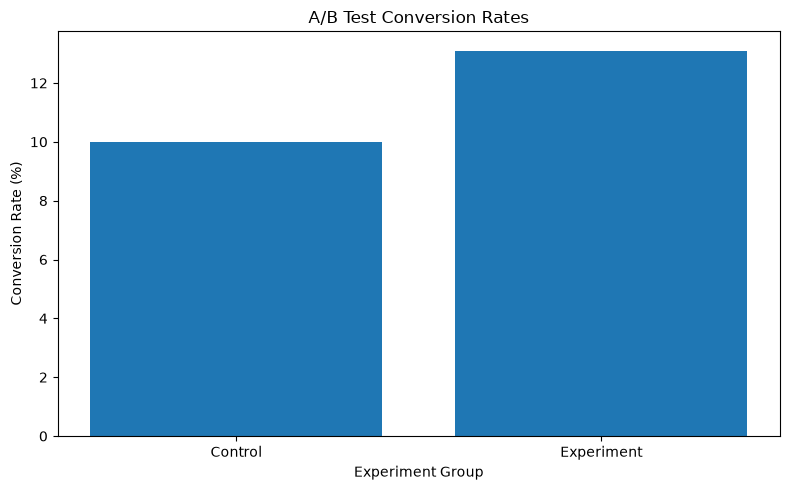

In [7]:
# A/B Test Conversion Rate Visualization

groups = conversion_summary["Group"]
rates = conversion_summary["ConversionRate"]

plt.figure(figsize=(8, 5))

plt.bar(groups, rates)

plt.title("A/B Test Conversion Rates")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate (%)")

plt.tight_layout()

plt.savefig(
    "day40_ab_conversion_rates.png",
    dpi=300
)

plt.show()

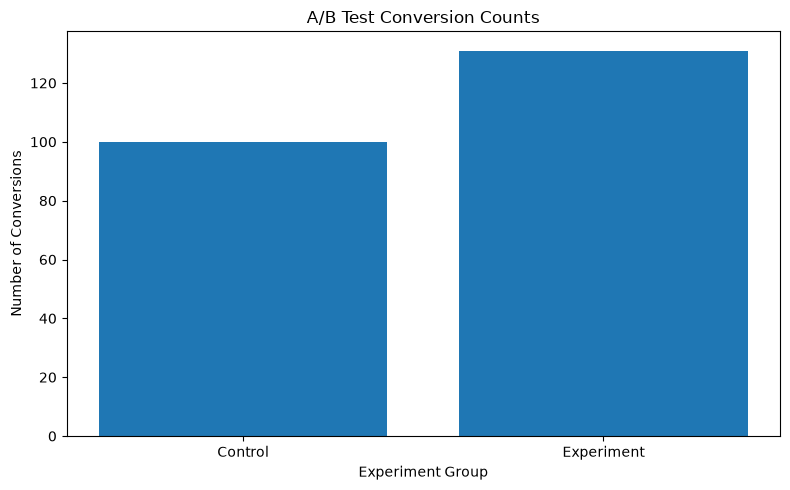

In [8]:
# Conversion Count Comparison

conversions_by_group = conversion_summary["Conversions"]

plt.figure(figsize=(8, 5))

plt.bar(groups, conversions_by_group)

plt.title("A/B Test Conversion Counts")
plt.xlabel("Experiment Group")
plt.ylabel("Number of Conversions")

plt.tight_layout()

plt.savefig(
    "day40_ab_conversion_counts.png",
    dpi=300
)

plt.show()

In [9]:
# Experiment Analysis Report

report = f"""
DAY 40 — A/B TESTING ANALYTICS REPORT
=====================================

EXPERIMENT DESIGN
-----------------
Control Group Users: {control_users}
Experiment Group Users: {experiment_users}

CONTROL GROUP
-------------
Conversions: {control_conversions}
Conversion Rate: {control_rate:.2f}%

EXPERIMENT GROUP
----------------
Conversions: {experiment_conversions}
Conversion Rate: {experiment_rate:.2f}%

PERFORMANCE CHANGE
------------------
Absolute Difference: {absolute_difference:.2f} percentage points
Relative Improvement: {relative_improvement:.2f}%

STATISTICAL TEST
----------------
Test: Two-Proportion Z-Test
Significance Level: {alpha}
Z-statistic: {z_stat:.4f}
P-value: {p_value:.6f}
Result: {significance_result}

BUSINESS INTERPRETATION
-----------------------
The experiment group was compared with the control group using
conversion rate and a two-proportion statistical significance test.

The statistical result should be considered together with practical
business impact before making a final product or marketing decision.
"""

print(report)

with open(
    "day40_experiment_analysis_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(report)

print("Experiment analysis report saved successfully!")


DAY 40 — A/B TESTING ANALYTICS REPORT

EXPERIMENT DESIGN
-----------------
Control Group Users: 1000
Experiment Group Users: 1000

CONTROL GROUP
-------------
Conversions: 100
Conversion Rate: 10.00%

EXPERIMENT GROUP
----------------
Conversions: 131
Conversion Rate: 13.10%

PERFORMANCE CHANGE
------------------
Absolute Difference: 3.10 percentage points
Relative Improvement: 31.00%

STATISTICAL TEST
----------------
Test: Two-Proportion Z-Test
Significance Level: 0.05
Z-statistic: -2.1687
P-value: 0.030103
Result: Statistically significant

BUSINESS INTERPRETATION
-----------------------
The experiment group was compared with the control group using
conversion rate and a two-proportion statistical significance test.

The statistical result should be considered together with practical
business impact before making a final product or marketing decision.

Experiment analysis report saved successfully!


In [10]:
statistical_results = pd.DataFrame({
    "Metric": [
        "Control Conversion Rate",
        "Experiment Conversion Rate",
        "Absolute Difference",
        "Relative Improvement",
        "Z-Statistic",
        "P-Value",
        "Significance Level"
    ],
    "Value": [
        control_rate,
        experiment_rate,
        absolute_difference,
        relative_improvement,
        z_stat,
        p_value,
        alpha
    ]
})

statistical_results = statistical_results.round(6)

statistical_results.to_csv(
    "day40_statistical_significance.csv",
    index=False
)

print("Statistical significance results saved!")

Statistical significance results saved!


In [12]:
# Business Recommendation

if p_value < alpha and experiment_rate > control_rate:
    recommendation = """
The experiment group showed a higher conversion rate than the control
group, and the difference was statistically significant.

Business Recommendation:
The experiment can be considered for further rollout, while monitoring
business impact and validating the result with additional testing.
"""
elif p_value < alpha and experiment_rate < control_rate:
    recommendation = """
The experiment group showed a lower conversion rate than the control
group, and the difference was statistically significant.

Business Recommendation:
The experiment should not be rolled out in its current form.
The tested change should be reviewed and potentially redesigned.
"""
else:
    recommendation = """
The observed difference between the experiment and control groups was
not statistically significant.

Business Recommendation:
Do not make a major business decision based only on this experiment.
Consider collecting more observations or running another test.
"""

print(recommendation)

with open(
    "day40_business_recommendation.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(recommendation)

print("Business recommendation saved successfully!")


The experiment group showed a higher conversion rate than the control
group, and the difference was statistically significant.

Business Recommendation:
The experiment can be considered for further rollout, while monitoring
business impact and validating the result with additional testing.

Business recommendation saved successfully!
